In [1]:
import sys
from pathlib import Path

print(Path.cwd().parent)
sys.path.insert(0, str(Path.cwd().parent))

d:\ai-learning\neutrilen


In [2]:
import os
from dotenv import load_dotenv

load_dotenv()

GROQ_API_KEY = os.getenv("GROQ_API_KEY")
USDA_API_KEY = os.getenv("USDA_API_KEY")
HF_TOKEN = os.getenv("HF_TOKEN")
DATABASE_URL = os.getenv("DATABASE_URL")

In [3]:
from db import get_user, fetch_goals, fetch_streak

USER_ID = "guest"

user = get_user(USER_ID)
goals = fetch_goals(USER_ID)
streak = fetch_streak(USER_ID)

print("User  :", dict(user))
print("Goals :", goals)
print("Streak:", dict(streak))

User  : {'id': 'guest', 'name': 'Guest', 'email': None, 'cal_goal': 2000, 'protein_g': 150, 'carbs_g': 200, 'fat_g': 65, 'diet_type': 'maintain', 'units': 'metric', 'created_at': datetime.datetime(2026, 6, 5, 9, 7, 12, 855482, tzinfo=datetime.timezone.utc), 'updated_at': datetime.datetime(2026, 6, 5, 9, 7, 12, 855482, tzinfo=datetime.timezone.utc)}
Goals : {'calories': 2000, 'protein': 150, 'carbs': 200, 'fat': 65}
Streak: {'user_id': 'guest', 'current': 0, 'longest': 0, 'last_log': None, 'badge_3': False, 'badge_7': False, 'badge_14': False, 'badge_30': False}


### Agent State


In [4]:
from typing import TypedDict, Optional
from pydantic import BaseModel


class NutritionEntry(BaseModel):
    food_name: str
    portion_g: Optional[float] = None
    calories: float
    protein: float
    carbs: float
    fat: float
    confidence: float = 1.0
    source: str = "groq"


class AgentState(TypedDict):
    user_id: str
    image_b64: Optional[str]
    raw_vision_text: str
    nutrition_entries: list[NutritionEntry]
    daily_total: dict
    goals: dict
    streak: int
    advice: str
    error: Optional[str]

### Image Loading


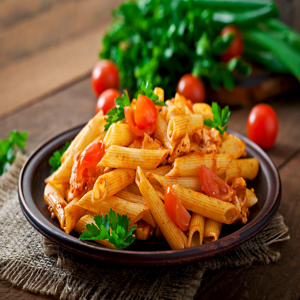

Base64 length: 178,992 chars


In [5]:
from PIL import Image
import io
from IPython.display import display
import base64

IMAGE_PATH = "test.jpg"


def load_image_b64(path: str, max_px: int = 1024) -> str:
    img = Image.open(path).convert("RGB")
    w, h = img.size
    if max(w, h) > max_px:
        scale = max_px / max(w, h)
        img = img.resize((int(w * scale), int(h * scale)), Image.LANCZOS)
    buf = io.BytesIO()
    img.save(buf, format="JPEG", quality=85)
    return base64.b64encode(buf.getvalue()).decode("utf-8")


image_b64 = load_image_b64(IMAGE_PATH)
display(Image.open(IMAGE_PATH).resize((300, 300)))
print(f"Base64 length: {len(image_b64):,} chars")

### Vision Node


In [6]:
from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage

d:\ai-learning\neutrilen\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
VISION_PROMPT = """
You are an expert nutritionist and Indian food analyst.

Analyse this food image in extreme detail. 

CRITICAL RULES:
- NEVER use "Vegetable Curry" or any generic dish name as a food item
- ALWAYS break every dish down to its individual ingredients
- Look inside each bowl carefully and identify every visible ingredient
- If a curry has potatoes, tomatoes, peas — list each one separately
- If dal has ghee on top — list dal and ghee separately
- Sambar should be broken into its vegetables and lentil base separately

For the vegetable curry bowl specifically:
- Look for: potato cubes, tomato pieces, green peas, capsicum, eggplant, curry leaves, onion, any other visible vegetables
- List EACH vegetable as its own entry

Return ONLY valid JSON — no markdown, no explanation:

{
  "dish_name": "string",
  "cuisine": "string", 
  "foods": [
    {
      "name":       "string",
      "role":       "string",
      "portion_g":  integer,
      "calories":   integer,
      "protein":    float,
      "carbs":      float,
      "fat":        float,
      "confidence": float
    }
  ],
  "total_calories":  integer,
  "analysis_notes":  "string"
}

Field rules:
- "name"       : SPECIFIC ingredient only — "potato cubes", "green peas", "curry leaves" NEVER generic names like "vegetable curry" or "mixed vegetables"
- "role"       : "carb" | "protein" | "vegetable" | "lentil" | "fat" | "sauce" | "garnish"
- "portion_g"  : estimated grams of that specific ingredient
- "confidence" : 0.0–1.0, lower if hidden under sauce or hard to see clearly

Break ALL of these down to individual ingredients.
"""

In [8]:
vision_llm = ChatGroq(
    model="meta-llama/llama-4-scout-17b-16e-instruct",
    api_key=GROQ_API_KEY,
    max_tokens=1024,
    temperature=0.1,
)

In [9]:
def vision_node(state: AgentState):
    print("Running vision Node...")
    try:
        msg = HumanMessage(
            content=[
                {"type": "text", "text": VISION_PROMPT},
                {
                    "type": "image_url",
                    "image_url": {
                        "url": f"data:image/jpeg;base64,{state['image_b64']}"
                    },
                },
            ]
        )
        response = vision_llm.invoke([msg])
        raw = response.content.strip()
        if raw.startswith("```"):
            raw = raw.split("```")[1]
            if raw.startswith("json"):
                raw = raw[4:]
        print("✅  Vision node complete")
        return {"raw_vision_text": raw.strip(), "error": None}
    except Exception as e:
        print(f"❌  Vision node failed: {e}")
        return {"raw_vision_text": "", "error": str(e)}

In [10]:
import json

test_state: AgentState = {
    "user_id": USER_ID,
    "image_b64": image_b64,
    "raw_vision_text": "",
    "nutrition_entries": [],
    "daily_total": {},
    "goals": fetch_goals(USER_ID),
    "streak": 0,
    "advice": "",
    "error": None,
}

vision_result = vision_node(test_state)
test_state.update(vision_result)

Running vision Node...
✅  Vision node complete


In [11]:
print("\nRaw Groq response:")
print(json.dumps(json.loads(test_state["raw_vision_text"]), indent=2))


Raw Groq response:
{
  "dish_name": "Pasta with Tomato Sauce",
  "cuisine": "Italian",
  "foods": [
    {
      "name": "penne pasta",
      "role": "carb",
      "portion_g": 250,
      "calories": 350,
      "protein": 0.9,
      "carbs": 70.0,
      "fat": 1.5,
      "confidence": 0.9
    },
    {
      "name": "tomato pieces",
      "role": "vegetable",
      "portion_g": 100,
      "calories": 20,
      "protein": 0.9,
      "carbs": 5.0,
      "fat": 0.2,
      "confidence": 0.8
    },
    {
      "name": "parsley leaves",
      "role": "garnish",
      "portion_g": 10,
      "calories": 1,
      "protein": 0.1,
      "carbs": 0.2,
      "fat": 0.0,
      "confidence": 0.8
    }
  ],
  "total_calories": 371,
  "analysis_notes": "The image appears to be a simple pasta dish with tomato sauce and parsley garnish. No other ingredients are visible."
}


### Nutrition Node


In [12]:
import requests

HF_API = "https://router.huggingface.co/hf-inference/models/nateraw/food"
HF_HEADERS = {"Authorization": f"Bearer {HF_TOKEN}", "Content-Type": "image/jpeg"}

conf_threshold = 0.7


def hf_classify_food(image_b64: str) -> dict:
    images_bytes = base64.b64decode(image_b64)
    response = requests.post(HF_API, headers=HF_HEADERS, data=images_bytes, timeout=15)
    results = response.json()
    print(results)
    if isinstance(results, list) and results:
        return {"label": results[0]["label"], "score": results[0]["score"]}
    return {"label": "unknown", "score": 0.0}


print(hf_classify_food(test_state["image_b64"]))

[{'label': 'pad_thai', 'score': 0.9211404919624329}, {'label': 'chicken_curry', 'score': 0.03745889663696289}, {'label': 'fried_rice', 'score': 0.0031450451351702213}, {'label': 'hot_and_sour_soup', 'score': 0.002038721926510334}, {'label': 'samosa', 'score': 0.0018041753210127354}]
{'label': 'pad_thai', 'score': 0.9211404919624329}


In [13]:
def nutrition_node(state: AgentState) -> dict:
    print("=== Nutrition Node ===")
    try:
        parsed = json.loads(state["raw_vision_text"])
        foods = parsed.get("foods", [])
        entries = []

        for f in foods:
            confidence = float(f.get("confidence", 1.0))
            if confidence < conf_threshold:
                print(
                    f"  Low confidence ({confidence:.2f}) for '{f['name']}' — trying HF fallback"
                )
                hf = hf_classify_food(state["image_b64"])
                if hf["score"] > confidence:
                    print(f"  HF override: '{hf['label']}' (score {hf['score']:.2f})")
                    f["name"] = hf["label"]
                    f["confidence"] = hf["score"]
                    f["source"] = "huggingface"
            entry = NutritionEntry(
                food_name=f.get("name", "unknown"),
                portion_g=f.get("portion_g"),
                calories=float(f.get("calories", 0)),
                protein=float(f.get("protein", 0)),
                carbs=float(f.get("carbs", 0)),
                fat=float(f.get("fat", 0)),
                confidence=float(f.get("confidence", 1.0)),
                source=f.get("source", "groq"),
            )
            entries.append(entry)
            print(
                f"  ✅  {entry.food_name}: {entry.calories} kcal | "
                f"P {entry.protein}g C {entry.carbs}g F {entry.fat}g "
                f"(conf {entry.confidence:.2f})"
            )

        print(f"\n✅  Nutrition node complete — {len(entries)} item(s) parsed")
        return {"nutrition_entries": entries, "error": None}
    except Exception as e:
        print(f"❌  Nutrition node failed: {e}")
        return {"nutrition_entries": [], "error": str(e)}


nutrition_result = nutrition_node(test_state)
test_state.update(nutrition_result)

=== Nutrition Node ===
  ✅  penne pasta: 350.0 kcal | P 0.9g C 70.0g F 1.5g (conf 0.90)
  ✅  tomato pieces: 20.0 kcal | P 0.9g C 5.0g F 0.2g (conf 0.80)
  ✅  parsley leaves: 1.0 kcal | P 0.1g C 0.2g F 0.0g (conf 0.80)

✅  Nutrition node complete — 3 item(s) parsed


### Memory Node


In [14]:
from db import (
    save_food_logs_bulk,
    fetch_daily_total,
    image_hash,
    get_cached_image,
    save_image_cache,
)


def memory_node(state: AgentState) -> dict:
    print("Memory node")
    try:
        entries = state["nutrition_entries"]
        if not entries:
            print("  No entries to save — skipping")
            return {"daily_total": dict(fetch_daily_total(state["user_id"]))}
        rows = [
            {
                "user_id": state["user_id"],
                "food_name": e.food_name,
                "calories": e.calories,
                "protein": e.protein,
                "carbs": e.carbs,
                "fat": e.fat,
                "portion_g": e.portion_g,
                "image_b64": state["image_b64"],
                "confidence": e.confidence,
                "source": e.source,
            }
            for e in entries
        ]
        saved = save_food_logs_bulk(rows)
        print(f"  Saved {len(saved)} row(s) to food_logs")

        if state.get("image_b64"):
            raw_bytes = base64.b64decode(state["image_b64"])
            h = image_hash(raw_bytes)
            first = entries[0]
            save_image_cache(
                img_hash=h,
                user_id=state["user_id"],
                food_name=first.food_name,
                calories=first.calories,
                protein=first.protein,
                carbs=first.carbs,
                fat=first.fat,
                portion_g=first.portion_g,
                confidence=first.confidence,
                source=first.source,
            )
            print(f"  Image cached (hash: {h[:8]}...)")

        daily = fetch_daily_total(state["user_id"])
        print(
            f"  Today's total → {daily['total_calories']} kcal | "
            f"P {daily['total_protein']}g C {daily['total_carbs']}g F {daily['total_fat']}g"
        )
        print("✅  Memory node complete")
        return {"daily_total": dict(daily), "error": None}
    except Exception as e:
        print(f"❌  Memory node failed: {e}")
        return {"daily_total": {}, "error": str(e)}


memory_result = memory_node(test_state)
test_state.update(memory_result)

Memory node
  Saved 3 row(s) to food_logs
  Image cached (hash: fb7572cb...)
  Today's total → 371.0 kcal | P 1.9g C 75.2g F 1.7g
✅  Memory node complete


### Goal Node


In [15]:
from langchain_core.messages import SystemMessage

advice_llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    api_key=GROQ_API_KEY,
    temperature=0.4,
    max_tokens=256,
)

In [16]:
def goal_node(state: AgentState) -> dict:
    print("Goal node")
    try:
        total = state["daily_total"]
        goals = state["goals"]

        remaining_kcal = goals["calories"] - total.get("total_calories", 0)
        remaining_protein = goals["protein"] - total.get("total_protein", 0)
        remaining_carbs = goals["carbs"] - total.get("total_carbs", 0)
        remaining_fat = goals["fat"] - total.get("total_fat", 0)

        prompt = f"""
        The user has eaten so far today:
        - Calories : {total.get("total_calories", 0):.0f} kcal (goal: {goals["calories"]}, remaining: {remaining_kcal:.0f})
        - Protein  : {total.get("total_protein", 0):.1f}g  (goal: {goals["protein"]}g,  remaining: {remaining_protein:.1f}g)
        - Carbs    : {total.get("total_carbs", 0):.1f}g  (goal: {goals["carbs"]}g,    remaining: {remaining_carbs:.1f}g)
        - Fat      : {total.get("total_fat", 0):.1f}g  (goal: {goals["fat"]}g,      remaining: {remaining_fat:.1f}g)

        Write a friendly 1-2 sentence summary and one specific suggestion for their next meal.
        """
        response = advice_llm.invoke(
            [
                SystemMessage(
                    content="You are a helpful nutrition coach. Keep responses short and motivating."
                ),
                HumanMessage(content=prompt),
            ]
        )

        advice = response.content.strip()
        print(f"✅  Goal node complete\n  Advice: {advice}")
        return {"advice": advice, "error": None}
    except Exception as e:
        print(f"❌  Goal node failed: {e}")
        return {"advice": "", "error": str(e)}


goal_result = goal_node(test_state)
test_state.update(goal_result)

Goal node
✅  Goal node complete
  Advice: You're off to a great start, but it's time to boost those protein and healthy fat numbers to support your overall nutrition goals. For your next meal, consider having a grilled chicken breast with avocado, which will not only add about 40g of protein but also a significant amount of healthy fats to get you closer to your daily targets.


### Streak Node


In [17]:
from db import update_streak


def streak_node(state: AgentState) -> dict:
    print("Running streak_node...")
    try:
        row = update_streak(state["user_id"])
        print(f"✅  Streak: {row['current']} day(s) | Longest: {row['longest']}")
        for days, key in [
            (3, "badge_3"),
            (7, "badge_7"),
            (14, "badge_14"),
            (30, "badge_30"),
        ]:
            if row[key]:
                print(f"  🏅  {days}-day badge earned!")
        return {"streak": row["current"], "error": None}
    except Exception as e:
        print(f"❌  Streak node failed: {e}")
        return {"streak": 0, "error": str(e)}


streak_result = streak_node(test_state)
test_state.update(streak_result)

Running streak_node...
✅  Streak: 1 day(s) | Longest: 1


In [18]:
from langgraph.graph import StateGraph, END

builder = StateGraph(AgentState)

builder.add_node("vision", vision_node)
builder.add_node("nutrition", nutrition_node)
builder.add_node("memory", memory_node)
builder.add_node("goals", goal_node)
builder.add_node("streak", streak_node)

builder.set_entry_point("vision")
builder.add_edge("vision", "nutrition")
builder.add_edge("nutrition", "memory")
builder.add_edge("memory", "goals")
builder.add_edge("goals", "streak")
builder.add_edge("streak", END)

nutrilens_graph = builder.compile()

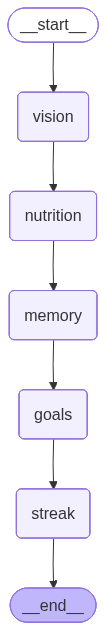

In [19]:
from IPython.display import Image, display

display(Image(nutrilens_graph.get_graph().draw_mermaid_png()))

In [20]:
initial_state: AgentState = {
    "user_id":           USER_ID,
    "image_b64":         image_b64,
    "raw_vision_text":   "",
    "nutrition_entries": [],
    "daily_total":       {},
    "goals":             fetch_goals(USER_ID),
    "streak":            0,
    "advice":            "",
    "error":             None,
}

print("=" * 50)
print("Running full LangGraph pipeline...")
print("=" * 50)

final_state = nutrilens_graph.invoke(initial_state)

print("\n" + "=" * 50)
print("FINAL STATE SUMMARY")
print("=" * 50)
print(f"Entries logged : {len(final_state['nutrition_entries'])}")
print(f"Daily total    : {final_state['daily_total'].get('total_calories', 0):.0f} kcal")
print(f"Streak         : {final_state['streak']} day(s)")
print(f"Advice         : {final_state['advice']}")
if final_state.get("error"):
    print(f"Error          : {final_state['error']}")

Running full LangGraph pipeline...
Running vision Node...
✅  Vision node complete
=== Nutrition Node ===
  ✅  penne pasta: 350.0 kcal | P 0.5g C 70.0g F 1.0g (conf 0.90)
  ✅  tomato pieces: 20.0 kcal | P 0.5g C 5.0g F 0.2g (conf 0.80)
  ✅  parsley leaves: 1.0 kcal | P 0.1g C 0.2g F 0.0g (conf 0.80)

✅  Nutrition node complete — 3 item(s) parsed
Memory node
  Saved 3 row(s) to food_logs
  Image cached (hash: fb7572cb...)
  Today's total → 742.0 kcal | P 3.0g C 150.4g F 2.9g
✅  Memory node complete
Goal node
✅  Goal node complete
  Advice: You're off to a great start, but it's time to boost those protein and fat numbers to reach your daily goals. For your next meal, consider having a grilled chicken breast with avocado, which will not only add about 40g of protein but also a significant amount of healthy fats to get you back on track.
Running streak_node...
✅  Streak: 1 day(s) | Longest: 1

FINAL STATE SUMMARY
Entries logged : 3
Daily total    : 742 kcal
Streak         : 1 day(s)
Advice 

In [21]:
from db import fetch_today_logs, fetch_daily_total, fetch_streak

print("── Today's food logs ──────────────────────────────")
logs = fetch_today_logs(USER_ID)
for log in logs:
    print(f"  [{log['id']}] {log['food_name']:20s} "
          f"{log['calories']:>6.0f} kcal  "
          f"P {log['protein']:>5.1f}g  "
          f"C {log['carbs']:>5.1f}g  "
          f"F {log['fat']:>5.1f}g  "
          f"({log['source']})")

print("\n── Daily total (from view) ─────────────────────────")
total = fetch_daily_total(USER_ID)
print(f"  Calories : {total['total_calories']:.0f}")
print(f"  Protein  : {total['total_protein']:.1f}g")
print(f"  Carbs    : {total['total_carbs']:.1f}g")
print(f"  Fat      : {total['total_fat']:.1f}g")
print(f"  Meals    : {total['meal_count']}")

print("\n── Streak ──────────────────────────────────────────")
streak = fetch_streak(USER_ID)
print(f"  Current  : {streak['current']} day(s)")
print(f"  Longest  : {streak['longest']} day(s)")
print(f"  Last log : {streak['last_log']}")

── Today's food logs ──────────────────────────────
  [1] penne pasta             350 kcal  P   0.9g  C  70.0g  F   1.5g  (groq)
  [2] tomato pieces            20 kcal  P   0.9g  C   5.0g  F   0.2g  (groq)
  [3] parsley leaves            1 kcal  P   0.1g  C   0.2g  F   0.0g  (groq)
  [4] penne pasta             350 kcal  P   0.5g  C  70.0g  F   1.0g  (groq)
  [5] tomato pieces            20 kcal  P   0.5g  C   5.0g  F   0.2g  (groq)
  [6] parsley leaves            1 kcal  P   0.1g  C   0.2g  F   0.0g  (groq)

── Daily total (from view) ─────────────────────────
  Calories : 742
  Protein  : 3.0g
  Carbs    : 150.4g
  Fat      : 2.9g
  Meals    : 6

── Streak ──────────────────────────────────────────
  Current  : 1 day(s)
  Longest  : 1 day(s)
  Last log : 2026-06-07


In [22]:
raw_bytes = base64.b64decode(image_b64)
h         = image_hash(raw_bytes)
cached    = get_cached_image(h)

if cached:
    print(f"✅  Cache hit for hash {h[:8]}...")
    print(f"   Food     : {cached['food_name']}")
    print(f"   Calories : {cached['calories']}")
    print(f"   Cached at: {cached['cached_at']}")
    print("\n   → Same image will skip Groq entirely next time.")
else:
    print("❌  No cache entry found — check memory_node ran correctly")

✅  Cache hit for hash fb7572cb...
   Food     : penne pasta
   Calories : 350.0
   Cached at: 2026-06-07 11:50:30.600230+00:00

   → Same image will skip Groq entirely next time.
